# Binomial Trees and Trinomial Trees

This notebook accompanies Chapter 06. It is organized to separate **reusable functions** from **chapter demonstrations** and to keep outputs clean and reproducible.

**Model scope:**
- European options with a binomial tree (CRR)
- American options with a binomial tree (early exercise)
- European options with a trinomial tree
- Small, readable tree visuals for intuition
- Cross-check vs Black–Scholes


## Load the Libs

In [1]:
# import Lib
import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as si
import networkx as nx


## Notebook Setup

In [2]:
# Setup
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
np.set_printoptions(suppress=True)


## Models Parameters

In [3]:
# Base parameters used throughout the chapter
S0 = 100.0
K = 105.0
T = 1.0
r = 0.05
sigma = 0.20

# Recommended step sizes:
# - For visuals (trees): keep small (n=2 or n=3) to avoid unreadable plots
N_VIS = 2

# - For convergence / comparison tables: use multiple values
N_TESTS = [2, 5, 10, 25, 50, 100, 200, 1000]


## Binomial Tree-Based Model for European Options

### Core Pricing Functions

This function returns prices (and do not plot) to keep the notebook maintainable and make unit testing straightforward.


In [4]:
def mb_binomial_tree_european(n, S, K, T, r, v, otype='call'):
    """
    Prices a European option using the Cox–Ross–Rubinstein (CRR) binomial tree model.

    This function constructs a recombining binomial tree for the underlying asset price
    and evaluates the option value by backward induction under the risk-neutral measure.
    The model supports European call and put options.

    Parameters
    ----------
    n : int
        Number of time steps in the binomial tree.
    S : float
        Initial price of the underlying asset.
    K : float
        Strike price of the option.
    T : float
        Time to maturity expressed in years.
    r : float
        Continuously compounded risk-free interest rate (annualized).
    v : float
        Volatility of the underlying asset (annualized standard deviation).
    otype : str, optional
        Option type: 'call' for a European call option or 'put' for a European put option.
        Default is 'call'.

    Returns
    -------
    float
        The estimated price of the European option at time t = 0.
    """
    dt = T/n
    u = math.exp(v * math.sqrt(dt))
    d = 1/u
    p = (math.exp(r*dt) - d)/(u - d)
    
    # Price tree
    price_tree = np.zeros([n+1, n+1])
    
    for i in range(n+1):
        for j in range(i+1):
            price_tree[j, i] = S * (u ** (i - j)) * (d ** j)

    # Option value
    option = np.zeros([n+1, n+1])

    # Calculate the option price at expiration
    if otype == 'call':
        option[:, n] = np.maximum(np.zeros(n+1), (price_tree[:, n] - K))
    elif otype == 'put':
        option[:, n] = np.maximum(np.zeros(n+1), (K - price_tree[:, n]))
    else:
        raise ValueError("Invalid option type. Please use 'call' or 'put'")

    # Calculate option price at t=0
    for i in range(n-1, -1, -1):
        for j in range(0, i+1):
            option[j, i] = math.exp(-r * dt) * (
                p * option[j, i + 1] + (1 - p) * option[j + 1, i + 1]
            )
    
    return option[0, 0]


### Numerical Example - Binomial (European) convergence table with timing

In [5]:
# Binomial (European) convergence table with timing
rows = []

for n in N_TESTS:
    start_time = time.perf_counter()
    
    call = mb_binomial_tree_european(n, S0, K, T, r, sigma, otype="call")
    put  = mb_binomial_tree_european(n, S0, K, T, r, sigma, otype="put")
    
    elapsed_time = time.perf_counter() - start_time

    rows.append({
        "n": n,
        "call_binomial": call,
        "put_binomial": put,
        "time_seconds": elapsed_time
    })

df_binom = pd.DataFrame(rows).set_index("n")
df_binom

,call_binomial,put_binomial,time_seconds
n,,,
2,8.0812,7.9603,0.0001
5,8.1277,8.0068,0.0001
10,8.1763,8.0554,0.0001
25,7.9941,7.8732,0.0007
50,8.0143,7.8934,0.0024
100,8.0262,7.9053,0.0211
200,8.0260,7.9051,0.0689
1000,8.0211,7.9001,1.0210


### Binomial tree visuals

For readability, we only visualize trees using a small number of steps (n < 11).


#### Visualizing the underlying prices with binomial trees

In [6]:
def mb_binomial_tree_underlying_prices_tree(n, S, K, T, r, v):
    """
    Visualizes the underlying price evolution in a CRR binomial tree.

    The function:
    1) Builds the recombining binomial tree of underlying prices.
    2) Plots the tree using small black nodes (bullet points) and prints the
       underlying value above each node for a clean, book-style figure.

    Parameters
    ----------
    n : int
        Number of time steps in the binomial tree.
    S : float
        Initial underlying price.
    K : float
        Strike price (not used in the plot; kept for consistency with other functions).
    T : float
        Time to maturity in years.
    r : float
        Continuously compounded risk-free rate (annualized).
    v : float
        Volatility (annualized).
    """
    # --- Model setup (unchanged logic) ---
    dt = T / n
    u = math.exp(v * math.sqrt(dt))
    d = 1 / u
    p = (math.exp(r * dt) - d) / (u - d)  # (kept; not used in this plot)

    # --- Build stock price tree ---
    stock = np.zeros([n + 1, n + 1])
    for i in range(n + 1):
        for j in range(i + 1):
            stock[j, i] = S * (u ** (i - j)) * (d ** j)

    # --- Build graph ---
    G = nx.Graph()

    # Positioning: x = time step, y = vertical spacing to form a diamond
    y_gap = 1.0  # increase for more vertical separation if needed

    for i in range(n + 1):
        for j in range(i + 1):
            x = i
            y = -y_gap * (2 * j - i)
            G.add_node((j, i), pos=(x, y), value=stock[j, i])

    for i in range(n):
        for j in range(i + 1):
            G.add_edge((j, i), (j, i + 1))       # up move
            G.add_edge((j, i), (j + 1, i + 1))   # down move

    pos = nx.get_node_attributes(G, "pos")
    values = nx.get_node_attributes(G, "value")

    # --- Plot (book-style) ---
    fig_w = max(6, 1.8 * (n + 1))     # scale width with n
    fig_h = max(3.5, 1.2 * (n + 1))   # scale height with n

    plt.figure(figsize=(fig_w, fig_h))

    # Edges: thin black lines
    nx.draw_networkx_edges(
        G, pos,
        edge_color="black",
        width=1.0
    )

    # Nodes: small black bullets
    nx.draw_networkx_nodes(
        G, pos,
        node_color="black",
        node_size=35,     # bullet size
        linewidths=0
    )

    # Labels: value printed slightly above each node
    # Build shifted positions for labels
    label_offset = 0.22 * y_gap
    label_pos = {k: (xy[0], xy[1] + label_offset) for k, xy in pos.items()}
    labels = {k: f"{val:.2f}" for k, val in values.items()}

    nx.draw_networkx_labels(
        G, label_pos,
        labels=labels,
        font_size=9,
        font_color="black",
        font_family="DejaVu Sans"
    )

    # Clean figure: no axes, tight layout
    plt.axis("off")
    plt.tight_layout()
    plt.show()


##### case where n = 2

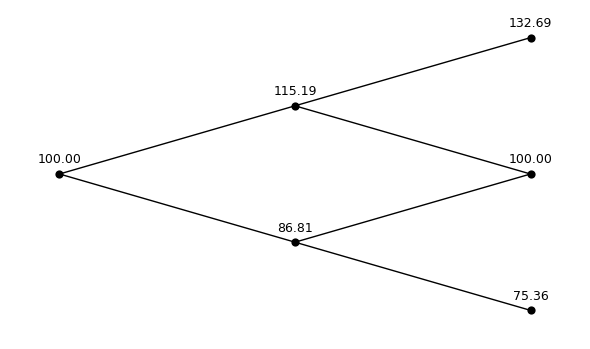

In [7]:
mb_binomial_tree_underlying_prices_tree(2, 100, 105, 1, 0.05, 0.2)

##### case where n = 5

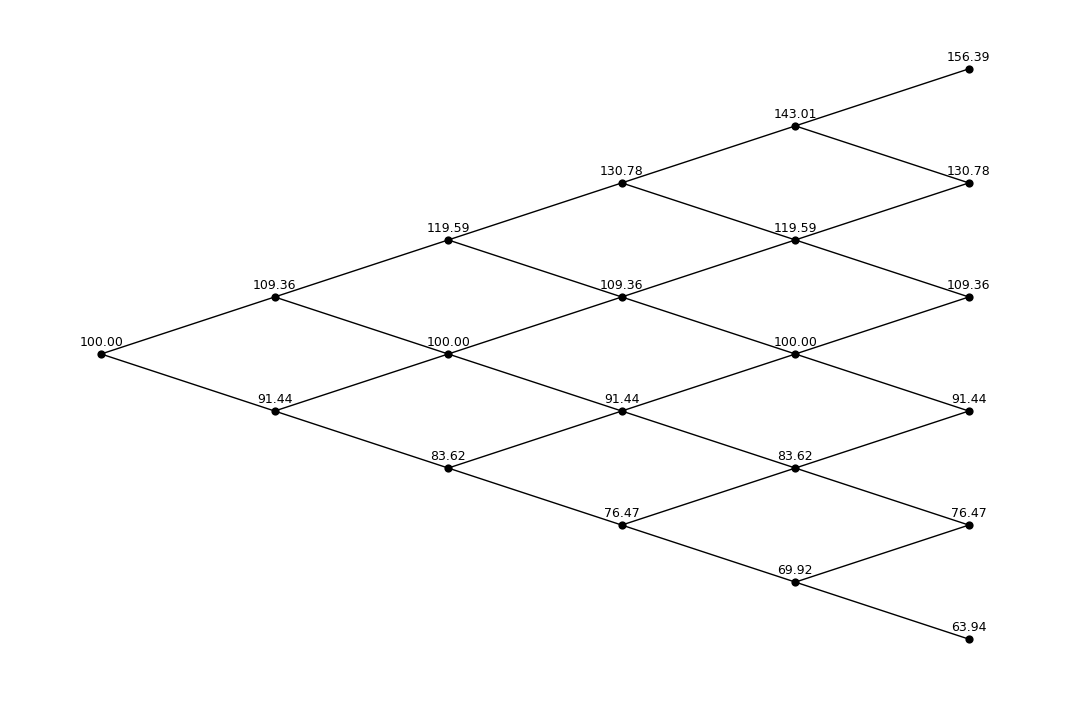

In [8]:
mb_binomial_tree_underlying_prices_tree(5, 100, 105, 1, 0.05, 0.2)

##### case where n = 10

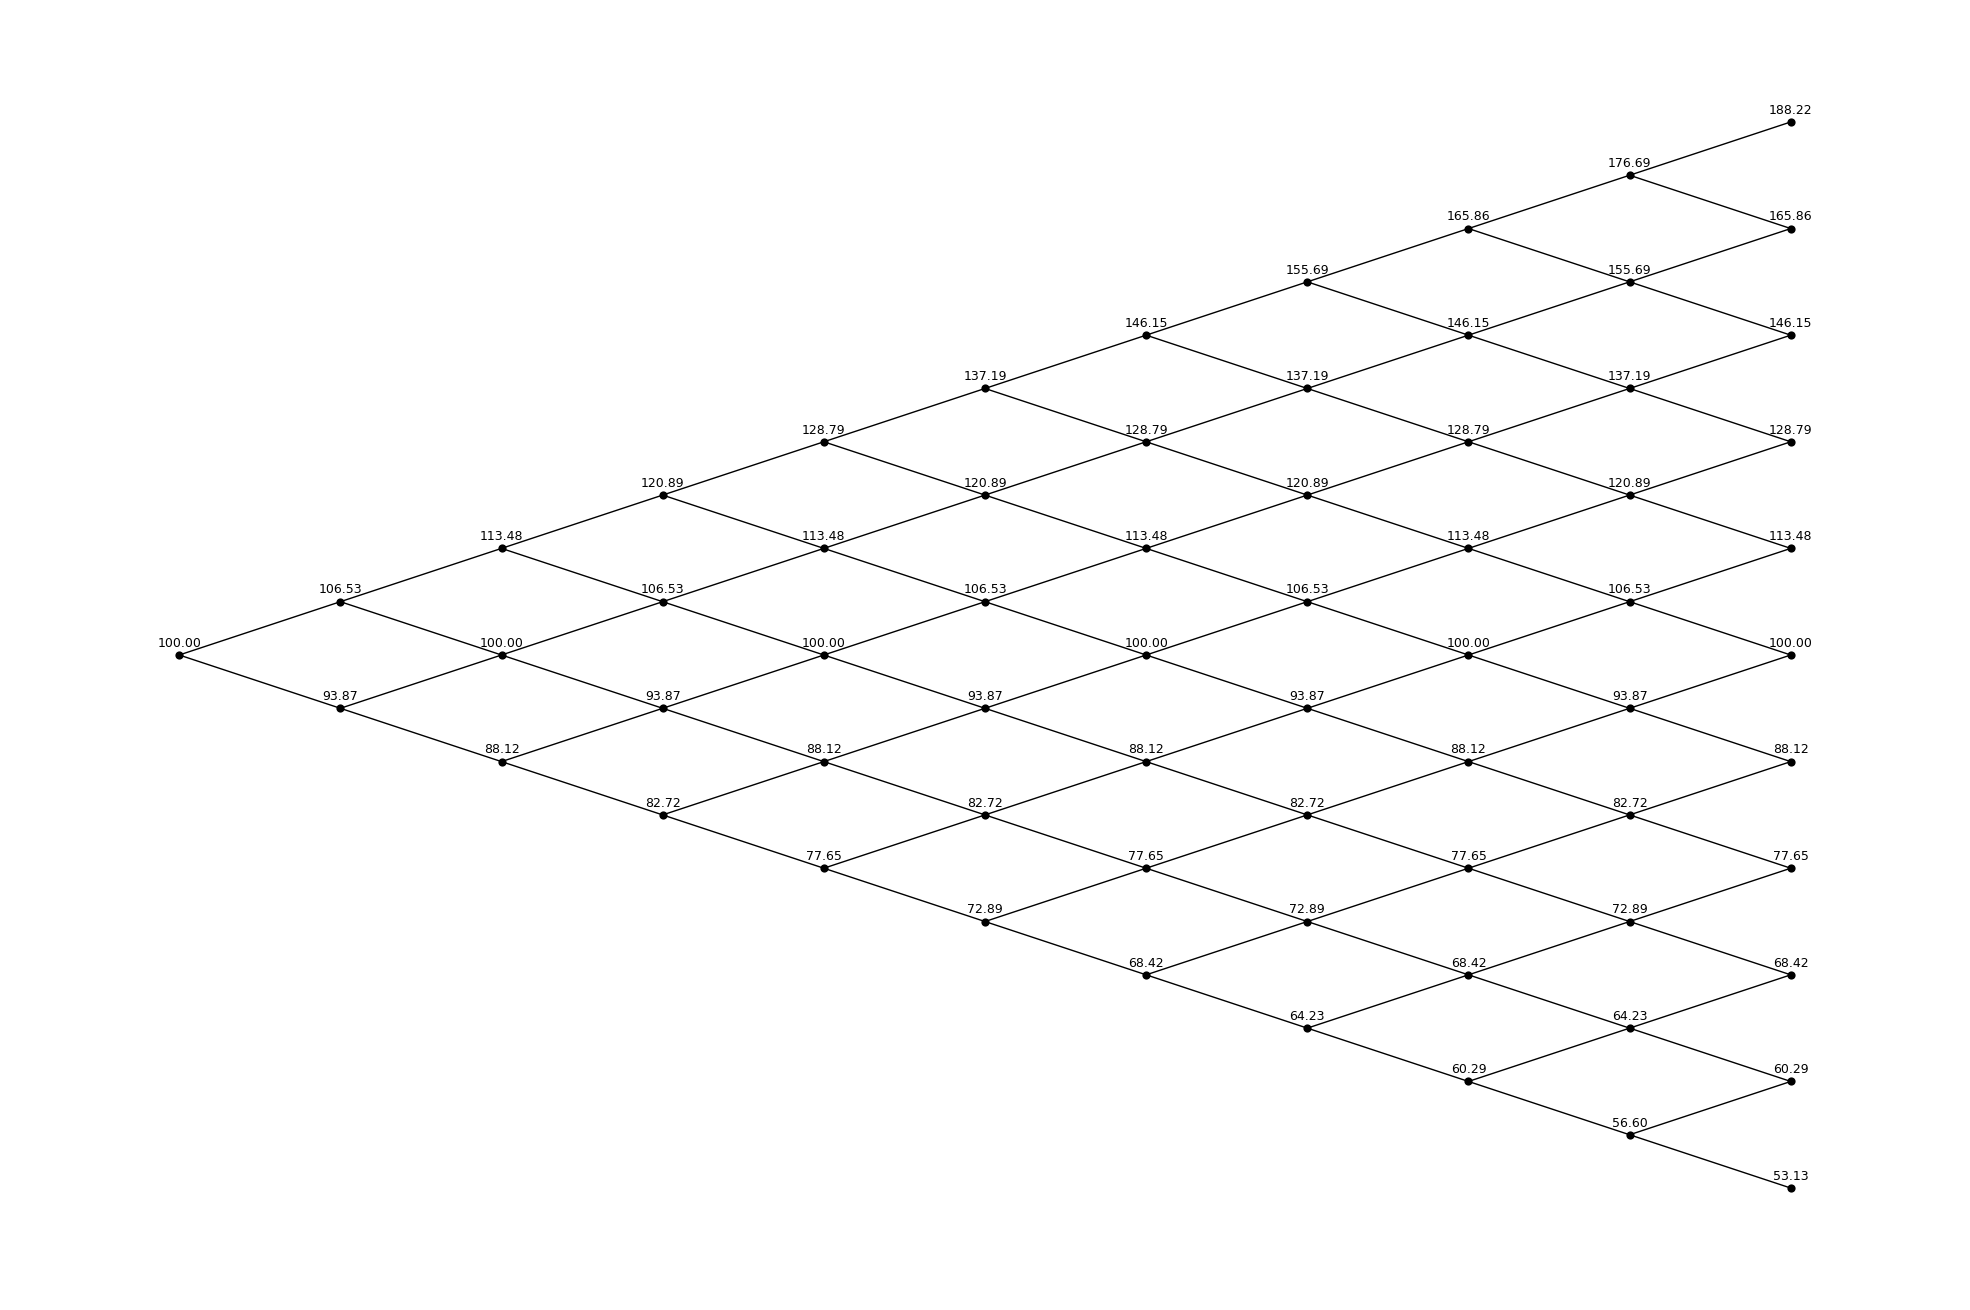

In [9]:
mb_binomial_tree_underlying_prices_tree(10, 100, 105, 1, 0.05, 0.2)

#### Visualizing the European Options prices with binomial trees

In [10]:
def mb_binomial_tree_european_tree(n, S, K, T, r, v, otype="call"):
    """
    Visualizes the European option value evolution using a CRR binomial tree.

    The tree is plotted in a clean, textbook-style format with:
    - Small black bullet nodes
    - Option values displayed above each node
    - Thin black connecting edges

    Parameters
    ----------
    n : int
        Number of time steps in the binomial tree.
    S : float
        Initial price of the underlying asset.
    K : float
        Strike price of the option.
    T : float
        Time to maturity expressed in years.
    r : float
        Continuously compounded risk-free interest rate (annualized).
    v : float
        Volatility of the underlying asset (annualized standard deviation).
    otype : str, optional
        Option type: 'call' for a European call option or 'put' for a European put option.
        Default is 'call'.
    """

    # --- Model setup ---
    dt = T / n
    u = math.exp(v * math.sqrt(dt))
    d = 1 / u
    p = (math.exp(r * dt) - d) / (u - d)

    # --- Underlying price tree ---
    stock = np.zeros([n + 1, n + 1])
    for i in range(n + 1):
        for j in range(i + 1):
            stock[j, i] = S * (u ** (i - j)) * (d ** j)

    # --- Option value tree (European) ---
    option = np.zeros([n + 1, n + 1])

    if otype == "call":
        option[:, n] = np.maximum(0, stock[:, n] - K)
    elif otype == "put":
        option[:, n] = np.maximum(0, K - stock[:, n])
    else:
        raise ValueError("Invalid option type. Please use 'call' or 'put'")

    # Backward induction (no early exercise for European options)
    disc = math.exp(-r * dt)
    for i in range(n - 1, -1, -1):
        for j in range(i + 1):
            option[j, i] = disc * (p * option[j, i + 1] + (1 - p) * option[j + 1, i + 1])

    # --- Build graph ---
    G = nx.Graph()
    y_gap = 1.0

    for i in range(n + 1):
        for j in range(i + 1):
            x = i
            y = -y_gap * (2 * j - i)
            G.add_node((j, i), pos=(x, y), value=option[j, i])

    for i in range(n):
        for j in range(i + 1):
            G.add_edge((j, i), (j, i + 1))
            G.add_edge((j, i), (j + 1, i + 1))

    pos = nx.get_node_attributes(G, "pos")
    values = nx.get_node_attributes(G, "value")

    # --- Plot ---
    fig_w = max(6, 1.8 * (n + 1))
    fig_h = max(3.5, 1.2 * (n + 1))
    plt.figure(figsize=(fig_w, fig_h))

    nx.draw_networkx_edges(G, pos, edge_color="black", width=1.0)
    nx.draw_networkx_nodes(G, pos, node_color="black", node_size=35, linewidths=0)

    label_offset = 0.22 * y_gap
    label_pos = {k: (xy[0], xy[1] + label_offset) for k, xy in pos.items()}
    labels = {k: f"{val:.2f}" for k, val in values.items()}

    nx.draw_networkx_labels(
        G,
        label_pos,
        labels=labels,
        font_size=9,
        font_color="black",
        font_family="DejaVu Sans"
    )

    plt.axis("off")
    plt.tight_layout()
    plt.show()


##### Call case where n = 2

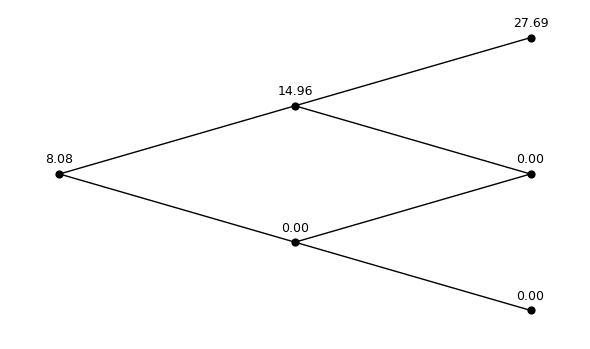

In [11]:
mb_binomial_tree_european_tree(2, 100, 105, 1, 0.05, 0.2, otype="call")

##### Call case where n = 5

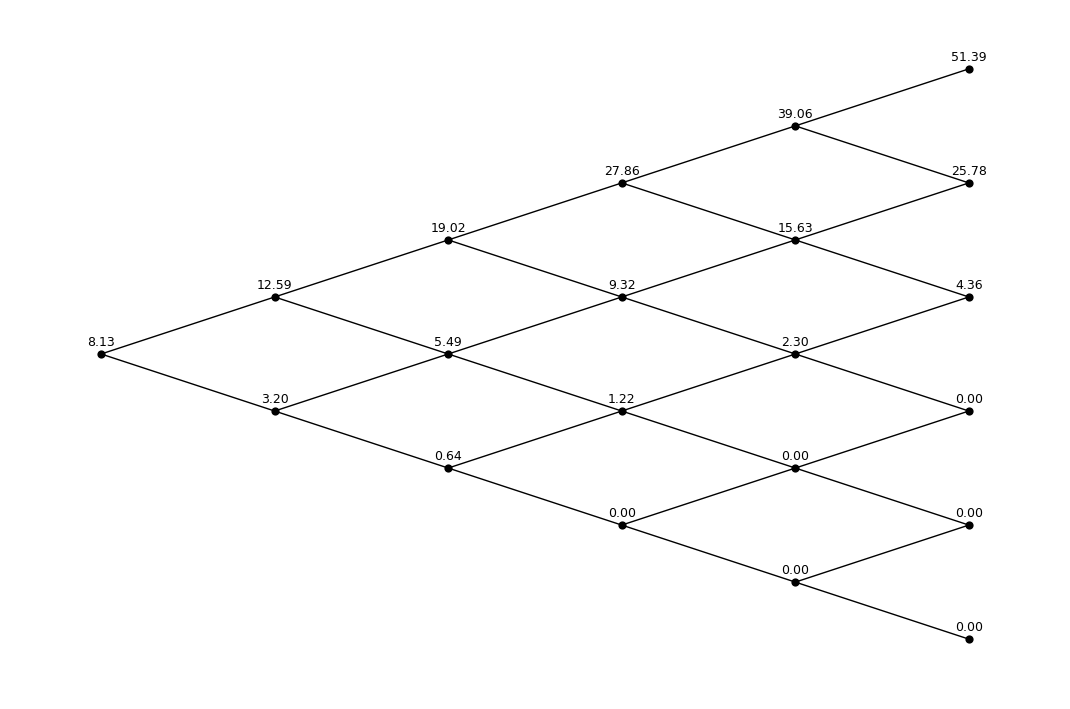

In [12]:
mb_binomial_tree_european_tree(5, 100, 105, 1, 0.05, 0.2, otype="call")

##### Put case where n = 2

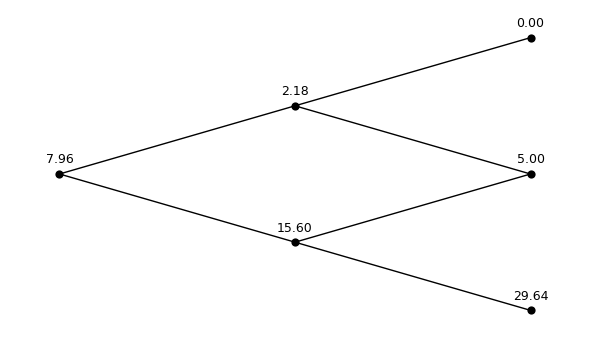

In [13]:
mb_binomial_tree_european_tree(2, 100, 105, 1, 0.05, 0.2, otype="put")

##### Put case where n = 5

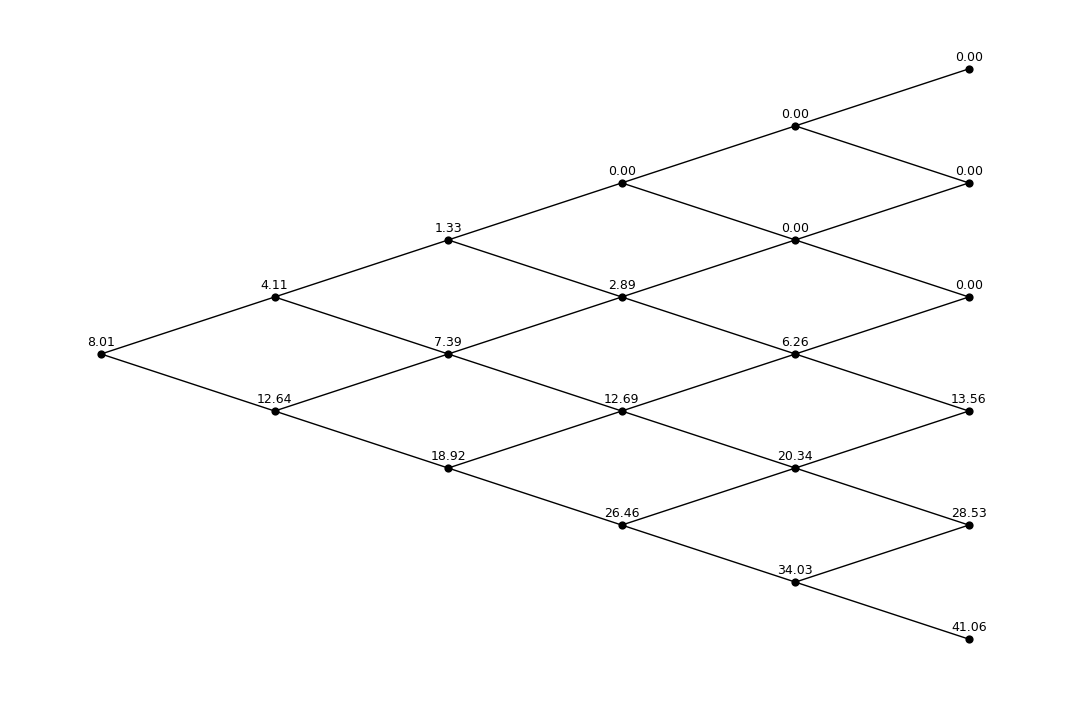

In [14]:
mb_binomial_tree_european_tree(5, 100, 105, 1, 0.05, 0.2, otype="put")

## Binomial Tree-Based Model for American Options

### Core Pricing Functions

This function returns prices (and do not plot) to keep the notebook maintainable and make unit testing straightforward.


##### Note:

American options differ from the European case only in the backward-induction step: at each node, the option value is the maximum of intrinsic value and continuation value.


In [15]:
def mb_binomial_tree_american(n, S, K, T, r, v, otype='call'):
    """
    Prices an American option using the Cox–Ross–Rubinstein (CRR) binomial tree model.

    This function constructs a recombining binomial tree for the underlying asset price
    and evaluates the option value by backward induction under the risk-neutral measure.
    At each node, the option value is computed as the maximum between the continuation
    value and the immediate exercise value, reflecting the early-exercise feature of
    American options.

    Parameters
    ----------
    n : int
        Number of time steps in the binomial tree.
    S : float
        Initial price of the underlying asset.
    K : float
        Strike price of the option.
    T : float
        Time to maturity expressed in years.
    r : float
        Continuously compounded risk-free interest rate (annualized).
    v : float
        Volatility of the underlying asset (annualized standard deviation).
    otype : str, optional
        Option type: 'call' for an American call option or 'put' for an American put option.
        Default is 'call'.

    Returns
    -------
    float
        The estimated price of the American option at time t = 0.
    """
    dt = T / n
    u = math.exp(v * math.sqrt(dt))
    d = 1 / u
    p = (math.exp(r * dt) - d) / (u - d)

    # Price tree
    price_tree = np.zeros([n + 1, n + 1])
    for i in range(n + 1):
        for j in range(i + 1):
            price_tree[j, i] = S * (u ** (i - j)) * (d ** j)

    # Option value tree
    option = np.zeros([n + 1, n + 1])

    # Payoff at maturity
    if otype == 'call':
        option[:, n] = np.maximum(0, price_tree[:, n] - K)
    elif otype == 'put':
        option[:, n] = np.maximum(0, K - price_tree[:, n])
    else:
        raise ValueError("Invalid option type. Please use 'call' or 'put'")

    # Backward induction with early exercise
    for i in range(n - 1, -1, -1):
        for j in range(i + 1):
            if otype == 'call':
                exercise = max(price_tree[j, i] - K, 0)
            else:  # put
                exercise = max(K - price_tree[j, i], 0)

            continuation = math.exp(-r * dt) * (
                p * option[j, i + 1] + (1 - p) * option[j + 1, i + 1]
            )

            option[j, i] = max(exercise, continuation)

    return option[0, 0]


### Numerical Example - Binomial (American) convergence table with timing

In [16]:
# Binomial (American) convergence table with timing
rows = []

for n in N_TESTS:
    start_time = time.perf_counter()
    
    call = mb_binomial_tree_american(n, S0, K, T, r, sigma, otype="call")
    put  = mb_binomial_tree_american(n, S0, K, T, r, sigma, otype="put")
    
    elapsed_time = time.perf_counter() - start_time

    rows.append({
        "n": n,
        "call_american": call,
        "put_american": put,
        "time_seconds": elapsed_time
    })

df_american = pd.DataFrame(rows).set_index("n")
df_american


,call_american,put_american,time_seconds
n,,,
2,8.0812,9.0883,0.0002
5,8.1277,8.7253,0.0004
10,8.1763,8.8550,0.0008
25,7.9941,8.7438,0.0032
50,8.0143,8.7357,0.0036
100,8.0262,8.7476,0.0318
200,8.0260,8.7436,0.0571
1000,8.0211,8.7403,1.5719


## Trinomial Tree-Based Model for European Options

### Core Pricing Functions

This function returns prices (and do not plot) to keep the notebook maintainable and make unit testing straightforward.


##### Note:

The trinomial tree extends the lattice by allowing three price moves per step (up / middle / down). This often improves numerical stability and convergence.


In [17]:
def mb_trinomial_tree_european(n, S, K, T, r, v, otype='call'):
    """
    Prices a European option using a recombining trinomial tree model.

    This function constructs a recombining trinomial tree for the underlying asset
    price (up / middle / down moves) and evaluates the option value by backward
    induction under a risk-neutral framework. The model supports European calls and puts.

    Parameters
    ----------
    n : int
        Number of time steps in the trinomial tree.
    S : float
        Initial price of the underlying asset.
    K : float
        Strike price of the option.
    T : float
        Time to maturity expressed in years.
    r : float
        Continuously compounded risk-free interest rate (annualized).
    v : float
        Volatility of the underlying asset (annualized standard deviation).
    otype : str, optional
        Option type: 'call' for a European call option or 'put' for a European put option.
        Default is 'call'.

    Returns
    -------
    float
        The estimated price of the European option at time t = 0.
    """
    dt = T / n

    # Trinomial parameters
    dx = v * math.sqrt(3 * dt)
    nu = r - 0.5 * v**2

    pu = 0.5 * ((v**2 * dt + (nu**2) * (dt**2)) / (dx**2) + (nu * dt) / dx)
    pd = 0.5 * ((v**2 * dt + (nu**2) * (dt**2)) / (dx**2) - (nu * dt) / dx)
    pm = 1.0 - pu - pd

    # Safety check (helps catch parameter regimes that break probabilities)
    if (pu < 0) or (pm < 0) or (pd < 0):
        raise ValueError(
            "Trinomial probabilities out of bounds. Try increasing n or review inputs."
        )

    # Arrays indexed by state k = i + n, where i ranges from -n..+n
    stock_price = np.zeros((2 * n + 1, n + 1))
    option_value = np.zeros((2 * n + 1, n + 1))

    # Build underlying prices for all reachable nodes
    for j in range(n + 1):
        for i in range(-j, j + 1):
            k = i + n
            stock_price[k, j] = S * math.exp(i * dx)

    # Payoff at maturity
    if otype == 'call':
        option_value[:, n] = np.maximum(stock_price[:, n] - K, 0.0)
    elif otype == 'put':
        option_value[:, n] = np.maximum(K - stock_price[:, n], 0.0)
    else:
        raise ValueError("Invalid option type. Please use 'call' or 'put'")

    # Backward induction
    disc = math.exp(-r * dt)
    for j in range(n - 1, -1, -1):
        for i in range(-j, j + 1):
            k = i + n
            option_value[k, j] = disc * (
                pu * option_value[k + 1, j + 1] +
                pm * option_value[k,     j + 1] +
                pd * option_value[k - 1, j + 1]
            )

    # The root node corresponds to i=0 => k=n at time j=0
    return option_value[n, 0]


### Numerical Example - Binomial (European) convergence table with timing

In [18]:
# Trinomial (European) convergence table with timing
rows = []

for n in N_TESTS:
    start_time = time.perf_counter()
    
    call = mb_trinomial_tree_european(n, S0, K, T, r, sigma, otype="call")
    put  = mb_trinomial_tree_european(n, S0, K, T, r, sigma, otype="put")
    
    elapsed_time = time.perf_counter() - start_time

    rows.append({
        "n": n,
        "call_trinomial": call,
        "put_trinomial": put,
        "time_seconds": elapsed_time
    })

df_trinom = pd.DataFrame(rows).set_index("n")
df_trinom


,call_trinomial,put_trinomial,time_seconds
n,,,
2,7.9121,7.7915,0.0002
5,8.1358,8.0149,0.0002
10,8.1181,7.9972,0.0007
25,8.0410,7.9201,0.0050
50,7.9825,7.8616,0.0112
100,8.0303,7.9094,0.0406
200,8.0119,7.8910,0.1268
1000,8.0223,7.9014,2.2587


### Trinomial tree visuals

As with the binomial case, keep visuals small so the figure stays readable.


In [19]:
def mb_trinomial_tree_underlying_prices_tree(n, S, K, T, r, v):
    """
    Visualizes the underlying price evolution in a recombining trinomial tree.

    The diagram is rendered in a clean textbook style:
    - small black bullet nodes
    - underlying prices displayed above each node
    - thin black edges
    - label font size = 9

    Parameters
    ----------
    n : int
        Number of time steps in the trinomial tree.
    S : float
        Initial price of the underlying asset.
    K : float
        Strike price (not used in the plot; kept for consistency with other functions).
    T : float
        Time to maturity expressed in years.
    r : float
        Continuously compounded risk-free interest rate (annualized).
    v : float
        Volatility of the underlying asset (annualized standard deviation).

    Returns
    -------
    None
        Displays the underlying price trinomial tree plot.
    """
    dt = T / n

    # Trinomial spacing parameter
    dx = v * math.sqrt(3 * dt)

    # Store underlying prices: rows represent state i in [-n, +n] mapped to index i+n
    stock_price = np.zeros((2 * n + 1, n + 1))

    for t in range(n + 1):
        for i in range(-t, t + 1):
            stock_price[i + n, t] = S * math.exp(i * dx)

    # Build graph
    G = nx.Graph()

    # Layout controls
    y_gap = 1.0  # vertical spacing between adjacent states

    for t in range(n + 1):
        for i in range(-t, t + 1):
            x = t
            y = y_gap * i  # symmetric around 0
            G.add_node((t, i), pos=(x, y), value=stock_price[i + n, t])

    for t in range(n):
        for i in range(-t, t + 1):
            # up, middle, down transitions
            G.add_edge((t, i), (t + 1, i + 1))
            G.add_edge((t, i), (t + 1, i))
            G.add_edge((t, i), (t + 1, i - 1))

    pos = nx.get_node_attributes(G, "pos")
    values = nx.get_node_attributes(G, "value")

    # Plot sizing (scales with n)
    fig_w = max(6, 1.8 * (n + 1))
    fig_h = max(3.5, 1.2 * (n + 1))
    plt.figure(figsize=(fig_w, fig_h))

    # Edges
    nx.draw_networkx_edges(G, pos, edge_color="black", width=1.0)

    # Nodes (black bullets)
    nx.draw_networkx_nodes(G, pos, node_color="black", node_size=35, linewidths=0)

    # Labels above nodes
    label_offset = 0.22 * y_gap
    label_pos = {k: (xy[0], xy[1] + label_offset) for k, xy in pos.items()}
    labels = {k: f"{val:.2f}" for k, val in values.items()}

    nx.draw_networkx_labels(
        G, label_pos,
        labels=labels,
        font_size=9,
        font_color="black",
        font_family="DejaVu Sans"
    )

    plt.axis("off")
    plt.tight_layout()
    plt.show()



##### Case where n = 2

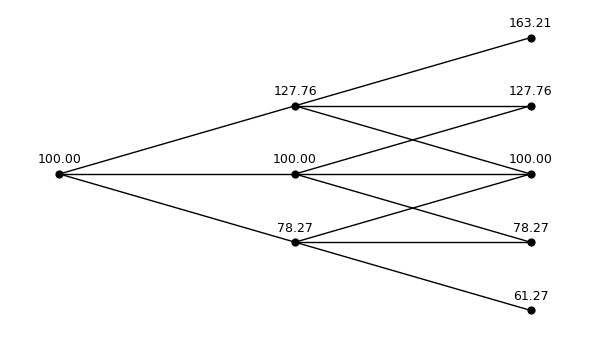

In [20]:
mb_trinomial_tree_underlying_prices_tree(2, 100, 105, 1, 0.05, 0.2)

##### Case where n = 5

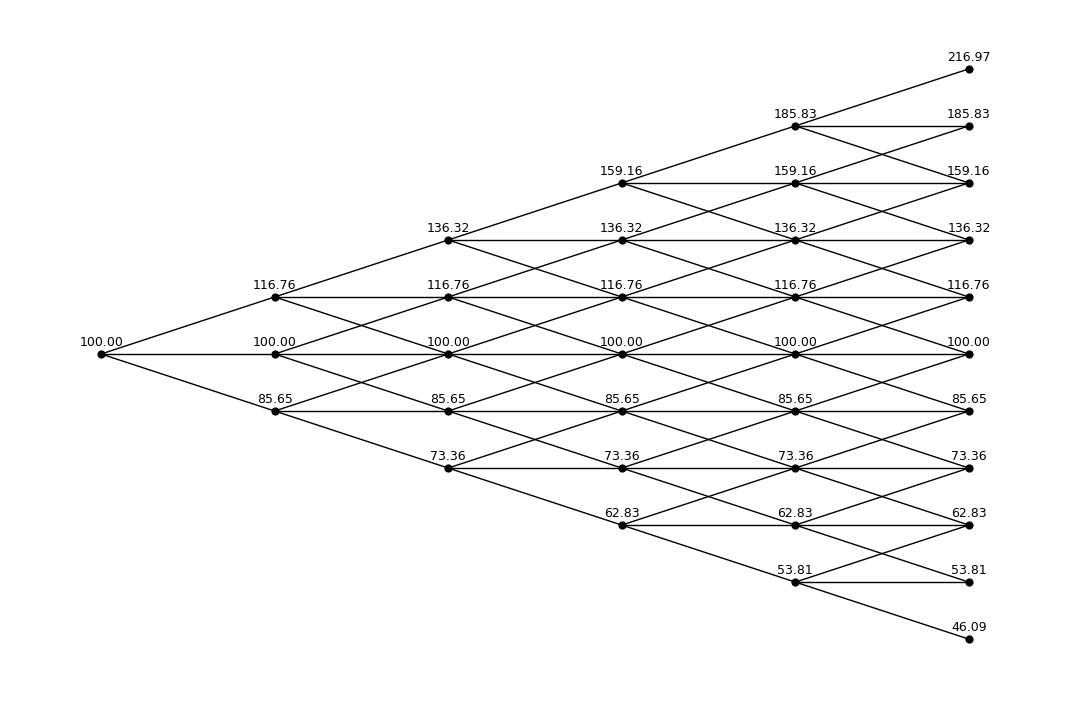

In [21]:
mb_trinomial_tree_underlying_prices_tree(5, 100, 105, 1, 0.05, 0.2)

In [22]:
def mb_trinomial_tree_european_tree(n, S, K, T, r, v, otype="call"):
    """
    Visualizes the European option value evolution in a recombining trinomial tree.

    Textbook style:
    - small black bullet nodes
    - option values above nodes
    - thin black edges
    - label font size = 9

    Parameters
    ----------
    n : int
        Number of time steps in the trinomial tree.
    S : float
        Initial price of the underlying asset.
    K : float
        Strike price.
    T : float
        Time to maturity in years.
    r : float
        Continuously compounded risk-free rate (annualized).
    v : float
        Volatility (annualized).
    otype : str, optional
        'call' or 'put'. Default is 'call'.
    """

    dt = T / n

    dx = v * math.sqrt(3 * dt)
    nu = r - 0.5 * v**2

    pu = 0.5 * ((v**2 * dt + (nu**2) * (dt**2)) / (dx**2) + (nu * dt) / dx)
    pd = 0.5 * ((v**2 * dt + (nu**2) * (dt**2)) / (dx**2) - (nu * dt) / dx)
    pm = 1.0 - pu - pd

    if (pu < 0) or (pm < 0) or (pd < 0):
        raise ValueError("Trinomial probabilities out of bounds. Try increasing n or review inputs.")

    stock_price = np.zeros((2 * n + 1, n + 1))
    option_value = np.zeros((2 * n + 1, n + 1))

    # Underlying prices for reachable nodes
    for t in range(n + 1):
        for i in range(-t, t + 1):
            stock_price[i + n, t] = S * math.exp(i * dx)

    # Payoff at maturity
    if otype == "call":
        option_value[:, n] = np.maximum(stock_price[:, n] - K, 0.0)
    elif otype == "put":
        option_value[:, n] = np.maximum(K - stock_price[:, n], 0.0)
    else:
        raise ValueError("Invalid option type. Please use 'call' or 'put'.")

    # Backward induction
    disc = math.exp(-r * dt)
    for t in range(n - 1, -1, -1):
        for i in range(-t, t + 1):
            k = i + n
            option_value[k, t] = disc * (
                pu * option_value[k + 1, t + 1] +
                pm * option_value[k,     t + 1] +
                pd * option_value[k - 1, t + 1]
            )

    # Build graph for plotting
    G = nx.Graph()
    y_gap = 1.0

    for t in range(n + 1):
        for i in range(-t, t + 1):
            G.add_node((t, i), pos=(t, y_gap * i), value=option_value[i + n, t])

    for t in range(n):
        for i in range(-t, t + 1):
            G.add_edge((t, i), (t + 1, i + 1))
            G.add_edge((t, i), (t + 1, i))
            G.add_edge((t, i), (t + 1, i - 1))

    pos = nx.get_node_attributes(G, "pos")
    values = nx.get_node_attributes(G, "value")

    fig_w = max(6, 1.8 * (n + 1))
    fig_h = max(3.5, 1.2 * (n + 1))
    plt.figure(figsize=(fig_w, fig_h))

    nx.draw_networkx_edges(G, pos, edge_color="black", width=1.0)
    nx.draw_networkx_nodes(G, pos, node_color="black", node_size=35, linewidths=0)

    label_offset = 0.22 * y_gap
    label_pos = {k: (xy[0], xy[1] + label_offset) for k, xy in pos.items()}
    labels = {k: f"{val:.2f}" for k, val in values.items()}

    nx.draw_networkx_labels(
        G, label_pos,
        labels=labels,
        font_size=9,
        font_color="black",
        font_family="DejaVu Sans"
    )

    plt.axis("off")
    plt.tight_layout()
    plt.show()


##### Call case where n = 2

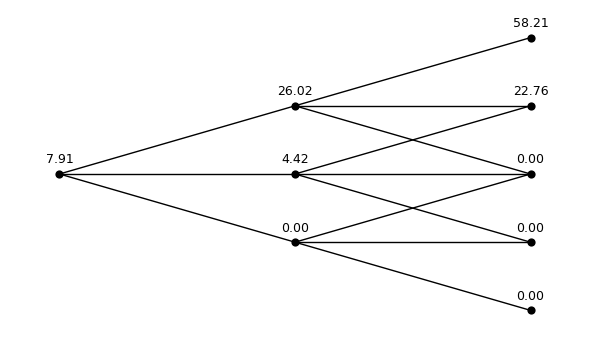

In [23]:
mb_trinomial_tree_european_tree(2, 100, 105, 1, 0.05, 0.2, otype="call")

##### Call case where n = 5

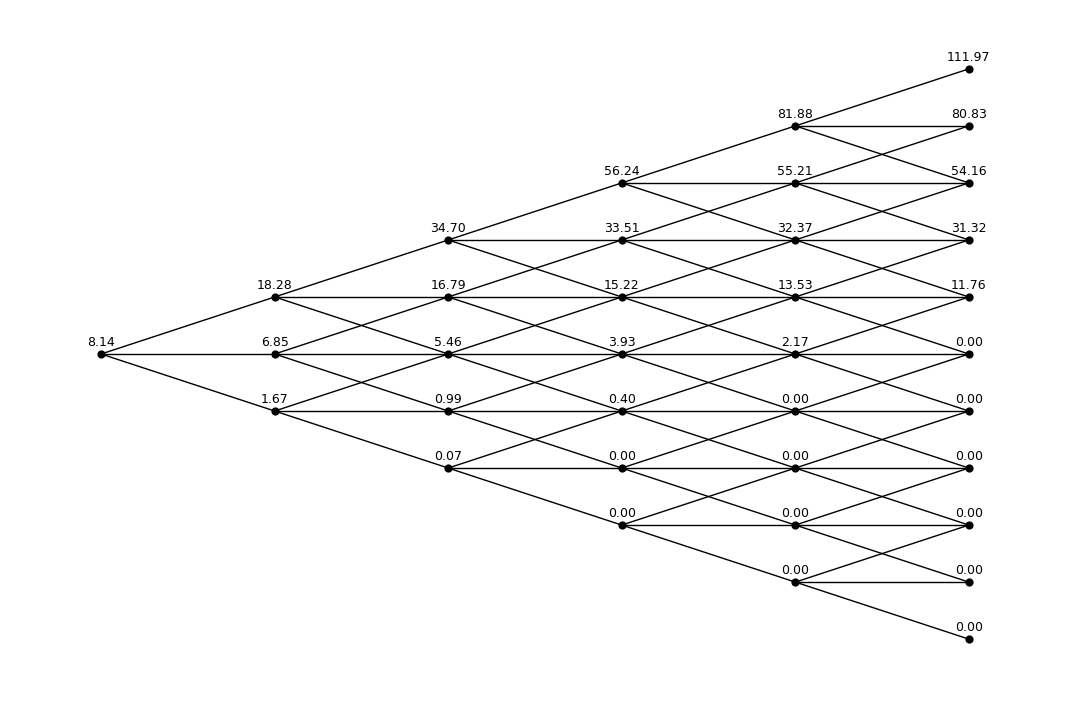

In [24]:
mb_trinomial_tree_european_tree(5, 100, 105, 1, 0.05, 0.2, otype="call")

##### Put case where n = 2

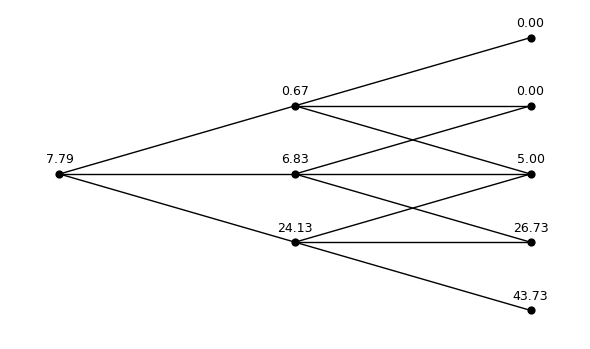

In [25]:
mb_trinomial_tree_european_tree(2, 100, 105, 1, 0.05, 0.2, otype="put")

##### Put case where n = 5

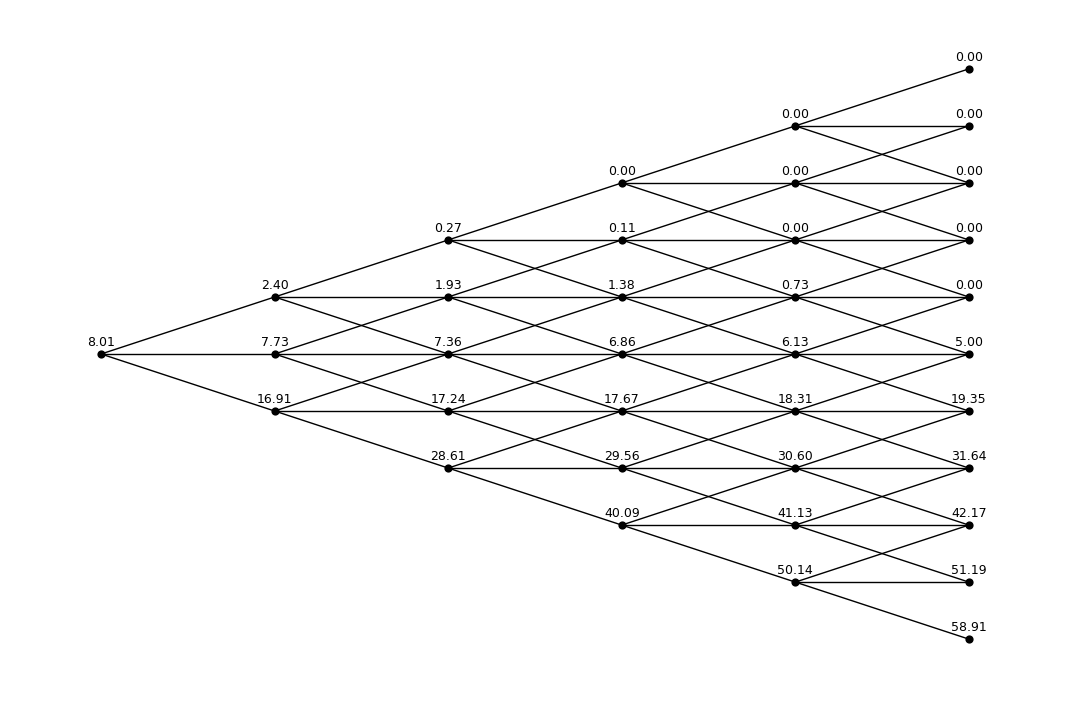

In [26]:
mb_trinomial_tree_european_tree(5, 100, 105, 1, 0.05, 0.2, otype="put")

## Black–Scholes benchmark

As a consistency check, compare tree-based prices (with a sufficiently large number of steps) to Black–Scholes prices for the same inputs.


In [27]:
def mb_bs_formula(S, K, T, r, v, option='call'):
    """
    Compact Black–Scholes closed-form formula using symbolic notation.
    Compute the Black–Scholes price of a European option.
    
    Parameters
    ----------
    S : float, spot price of the underlying asset
    K : float, strike price
    T : float, time to maturity (in years)
    r : float, risk-free interest rate
    v : float, volatility of the underlying asset
    option : str, 'call' or 'put'

    Returns
    -------
    float, Black–Scholes option price
    """
    d1 = (np.log(S / K) + (r + 0.5 * v**2) * T) / (v * np.sqrt(T))
    d2 = d1 - v * np.sqrt(T)

    if option == 'call':
        return S * si.norm.cdf(d1) - K * np.exp(-r * T) * si.norm.cdf(d2)

    elif option == 'put':
        return K * np.exp(-r * T) * si.norm.cdf(-d2) - S * si.norm.cdf(-d1)

    else:
        raise ValueError("Option type must be 'call' or 'put'.")


### Numerical Example - Benchmark comparison with % differences: BS vs Binomial vs Trinomial

In [28]:
# Benchmark comparison with % differences: BS vs Binomial vs Trinomial
N_COMPARE = N_TESTS

# Black–Scholes benchmark (independent of n)
bs_call = mb_bs_formula(S0, K, T, r, sigma, option="call")
bs_put  = mb_bs_formula(S0, K, T, r, sigma, option="put")

rows = []

for n in N_COMPARE:
    # ----- Call -----
    bin_call = mb_binomial_tree_european(n, S0, K, T, r, sigma, otype="call")
    tri_call = mb_trinomial_tree_european(n, S0, K, T, r, sigma, otype="call")

    rows.append({
        "Option": "Call",
        "n": n,
        "Black–Scholes": bs_call,
        "Binomial": bin_call,
        "Trinomial": tri_call,
        "Binomial vs BS (%)": 100 * (bin_call - bs_call) / bs_call,
        "Trinomial vs BS (%)": 100 * (tri_call - bs_call) / bs_call,
        "Binomial vs Trinomial (%)": 100 * (bin_call - tri_call) / tri_call,
    })

    # ----- Put -----
    bin_put = mb_binomial_tree_european(n, S0, K, T, r, sigma, otype="put")
    tri_put = mb_trinomial_tree_european(n, S0, K, T, r, sigma, otype="put")

    rows.append({
        "Option": "Put",
        "n": n,
        "Black–Scholes": bs_put,
        "Binomial": bin_put,
        "Trinomial": tri_put,
        "Binomial vs BS (%)": 100 * (bin_put - bs_put) / bs_put,
        "Trinomial vs BS (%)": 100 * (tri_put - bs_put) / bs_put,
        "Binomial vs Trinomial (%)": 100 * (bin_put - tri_put) / tri_put,
    })

df_compare = (
    pd.DataFrame(rows)
      .set_index(["Option", "n"])
      .sort_index()
      .round(4)
)

df_compare


Black–Scholes  Binomial  Trinomial  Binomial vs BS (%)  \
Option n                                                              
Call   2            8.0214    8.0812     7.9121              0.7467   
       5            8.0214    8.1277     8.1358              1.3258   
       10           8.0214    8.1763     8.1181              1.9317   
       25           8.0214    7.9941     8.0410             -0.3396   
       50           8.0214    8.0143     7.9825             -0.0884   
       100          8.0214    8.0262     8.0303              0.0608   
       200          8.0214    8.0260     8.0119              0.0579   
       1000         8.0214    8.0211     8.0223             -0.0036   
Put    2            7.9004    7.9603     7.7915              0.7581   
       5            7.9004    8.0068     8.0149              1.3461   
       10           7.9004    8.0554     7.9972              1.9612   
       25           7.9004    7.8732     7.9201             -0.3448   
       50           7.9004    7.8934     7.8616             -0.0897   
       100          7.9004    7.9053     7.9094              0.0617   
       200          7.9004    7.9051     7.8910              0.0588   
       1000         7.9004    7.9001     7.9014             -0.0037   

             Trinomial vs BS (%)  Binomial vs Trinomial (%)  
Option n                                                     
Call   2                 -1.3618                     2.1376  
       5                  1.4268                    -0.0996  
       10                 1.2058                     0.7172  
       25                 0.2456                    -0.5837  
       50                -0.4848                     0.3983  
       100                0.1113                    -0.0505  
       200               -0.1178                     0.1759  
       1000               0.0121                    -0.0157  
Put    2                 -1.3789                     2.1669  
       5                  1.4492                    -0.1017  
       10                 1.2244                     0.7279  
       25                 0.2493                    -0.5927  
       50                -0.4922                     0.4044  
       100                0.1130                    -0.0512  
       200               -0.1196                     0.1786  
       1000               0.0122                    -0.0159